In [27]:
# ============================================================
# CELL 1 — CONFIG (edit only this cell)
# ============================================================
TICKER            = "ALC"
PROJECTION_YEARS  = 5
ERP               = 0.055   # Equity Risk Premium (Damodaran)
SIZE_PREMIUM      = 0.0     # Add manually for small caps

In [28]:
# ============================================================
# CELL 2 — IMPORTS & INSTALLS
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime, date

pd.set_option("display.float_format", "{:,.2f}".format)
print("All imports successful.")

All imports successful.


In [29]:
# ============================================================
# CELL 3 — DATA FETCH
# ============================================================

tkr = yf.Ticker(TICKER)
info = tkr.info

# ── Validate ticker ──────────────────────────────────────────
if not info or info.get("regularMarketPrice") is None and info.get("currentPrice") is None:
    print(f"ERROR: Ticker '{TICKER}' not found or returned no data.")
    raise SystemExit(1)

# ── Helper: safe get from info ────────────────────────────────
def ig(key, default=None):
    v = info.get(key)
    return v if v not in (None, "", 0) else default

# ── Basic info ────────────────────────────────────────────────
current_price       = ig("currentPrice") or ig("regularMarketPrice", 0)
shares_outstanding  = ig("sharesOutstanding", 0)
market_cap          = ig("marketCap", 0)
beta                = ig("beta", 1.0)
sector              = ig("sector", "default")
industry            = ig("industry", "N/A")
company_name        = ig("longName", TICKER)
ebitda_info         = ig("ebitda", 0)
ev_info             = ig("enterpriseValue", 0)
ev_ebitda_info      = ig("enterpriseToEbitda")
trailing_pe         = ig("trailingPE")
forward_pe          = ig("forwardPE")
dividend_rate       = ig("dividendRate", 0)

# ── Financials ────────────────────────────────────────────────
def get_row(df, *keys):
    """Return first matching row across multiple possible key names."""
    if df is None or df.empty:
        return pd.Series(dtype=float)
    for k in keys:
        if k in df.index:
            return df.loc[k].astype(float)
    return pd.Series(dtype=float)

fin  = tkr.financials        # income statement (annual)
cf   = tkr.cashflow          # cash flow statement (annual)
bs   = tkr.balance_sheet     # balance sheet (annual)

def last4(series):
    """Take last 4 cols of a row series, sort oldest→newest."""
    s = series.dropna()
    s = s.sort_index()  # ascending date
    return s.iloc[-4:] if len(s) >= 4 else s

rev_raw  = last4(get_row(fin, "Total Revenue", "Revenue"))
if rev_raw.empty:
    print(f"ERROR: No revenue data found for '{TICKER}'.")
    raise SystemExit(1)

ebit_raw = last4(get_row(fin, "EBIT", "Operating Income"))
ni_raw   = last4(get_row(fin, "Net Income", "Net Income Common Stockholders"))
tax_raw  = last4(get_row(fin, "Tax Provision", "Income Tax Expense"))
pbi_raw  = last4(get_row(fin, "Pretax Income", "Income Before Tax"))
ie_raw   = last4(get_row(fin, "Interest Expense",
                          "Interest Expense Non Operating"))

da_raw   = last4(get_row(cf, "Depreciation And Amortization",
                          "Depreciation", "DepreciationAndAmortization"))
capex_raw= last4(get_row(cf, "Capital Expenditure",
                          "Purchase Of Property Plant And Equipment"))
opcf_raw = last4(get_row(cf, "Operating Cash Flow",
                          "Cash Flow From Continuing Operating Activities"))

# Align all series to revenue index
idx = rev_raw.index

def align(s, fallback=0.0):
    return s.reindex(idx).fillna(fallback)

revenue        = rev_raw.values.astype(float)
ebit           = align(ebit_raw).values
da             = align(da_raw).values
capex          = np.abs(align(capex_raw).values)   # ensure positive
net_income     = align(ni_raw).values
opcf           = align(opcf_raw).values
tax_provision  = align(tax_raw).values
pretax_income  = align(pbi_raw).values
interest_exp   = np.abs(align(ie_raw).values)

ebitda         = ebit + da
fiscal_years   = [d.year for d in idx]

# ── Balance sheet items ───────────────────────────────────────
bs_debt = get_row(bs, "Total Debt", "Long Term Debt")
bs_cash = get_row(bs, "Cash And Cash Equivalents",
                  "Cash Cash Equivalents And Short Term Investments")

total_debt = float(bs_debt.iloc[0]) if not bs_debt.empty else ig("totalDebt", 0)
cash       = float(bs_cash.iloc[0]) if not bs_cash.empty else ig("totalCash", 0)
net_debt   = total_debt - cash

# ── 10Y Treasury ──────────────────────────────────────────────
try:
    fred_df = web.DataReader("DGS10", "fred",
                             start="2024-01-01", end=date.today())
    rf_rate = float(fred_df.dropna().iloc[-1].values[0]) / 100
    rf_src  = "FRED"
except Exception:
    rf_rate = 0.043
    rf_src  = "fallback (4.3%)"

# ── Historical P/E percentile ─────────────────────────────────
current_pe_percentile = np.nan
pe_status             = "P/E history unavailable"
hist_pe_series        = pd.Series(dtype=float)

try:
    qfin    = tkr.quarterly_financials
    eps_row = get_row(qfin, "Diluted EPS", "Basic EPS", "Reported EPS")
    if not eps_row.empty:
        eps_sorted = eps_row.sort_index()           # ascending date
        eps_ttm    = eps_sorted.rolling(4).sum().dropna()

        hist_px = tkr.history(period="10y", auto_adjust=False)["Close"]
        # Normalize price index to tz-naive
        if hist_px.index.tz is not None:
            hist_px.index = hist_px.index.tz_convert(None)

        pe_list = []
        for dt, eps_val in eps_ttm.items():
            if eps_val <= 0:
                continue
            # Normalize EPS timestamp to tz-naive
            ts = pd.Timestamp(dt)
            dt_naive = ts.tz_convert(None) if ts.tzinfo is not None else ts
            candidates = hist_px[hist_px.index >= dt_naive]
            if candidates.empty:
                continue
            pe_list.append(float(candidates.iloc[0]) / eps_val)

        raw_pe = pd.Series(pe_list, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
        hist_pe_series = raw_pe[(raw_pe > 0) & (raw_pe < 200)]

    if trailing_pe and len(hist_pe_series) >= 8:
        current_pe_percentile = stats.percentileofscore(
            hist_pe_series.values, trailing_pe, kind="weak"
        )
        if current_pe_percentile >= 90:
            pe_status = "Historically expensive"
        elif current_pe_percentile >= 75:
            pe_status = "Above normal valuation"
        elif current_pe_percentile <= 10:
            pe_status = "Historically cheap"
        elif current_pe_percentile <= 25:
            pe_status = "Below normal valuation"
        else:
            pe_status = "Within normal historical range"
    elif trailing_pe:
        pe_status = "N/A (insufficient P/E history)"
except Exception:
    current_pe_percentile = np.nan
    pe_status             = "P/E history unavailable"

# ── Summary print ─────────────────────────────────────────────
nd_ebitda  = net_debt / ebitda[-1] if ebitda[-1] != 0 else float("nan")
tpe_str    = f"{trailing_pe:.1f}x" if trailing_pe else "N/A"
pe_pct_str = (f"{current_pe_percentile:.0f}th percentile"
              if not np.isnan(current_pe_percentile) else "N/A")

print(f"={'='*65}")
print(f"  COMPANY DATA — {company_name} ({TICKER})")
print(f"{'='*67}")
rows = [
    ("Company",              company_name),
    ("Sector",               sector),
    ("Industry",             industry),
    ("Current Price",        f"${current_price:,.2f}"),
    ("Market Cap",           f"${market_cap/1e6:,.0f}M"),
    ("Enterprise Value",     f"${ev_info/1e6:,.0f}M"),
    ("Net Debt",             f"${net_debt/1e6:,.0f}M"),
    ("Net Debt/EBITDA",      f"{nd_ebitda:.2f}x"),
    ("Beta",                 f"{beta:.2f}"),
    ("10Y Treasury",         f"{rf_rate*100:.2f}% ({rf_src})"),
    ("Trailing P/E",         tpe_str),
    ("P/E Percentile (10Y)", pe_pct_str),
    ("P/E Valuation Signal", pe_status),
]
for k, v in rows:
    print(f"  {k:<22} {v}")
print()

  COMPANY DATA — Alcon Inc. (ALC)
  Company                Alcon Inc.
  Sector                 Healthcare
  Industry               Medical Instruments & Supplies
  Current Price          $81.32
  Market Cap             $40,646M
  Enterprise Value       $43,273M
  Net Debt               $nanM
  Net Debt/EBITDA        nanx
  Beta                   0.74
  10Y Treasury           4.32% (FRED)
  Trailing P/E           41.1x
  P/E Percentile (10Y)   N/A
  P/E Valuation Signal   N/A (insufficient P/E history)



In [30]:
# ============================================================
# CELL 4 — HISTORICAL FINANCIALS TABLE
# ============================================================

eff_tax = np.where(pretax_income != 0, tax_provision / pretax_income, np.nan)

col_labels = [f"FY{y}A" for y in fiscal_years]

def fmt_m(arr):
    return [f"${v/1e6:>12,.0f}M" for v in arr]

def fmt_pct(arr):
    return [f"{v*100:>10.1f}%" for v in arr]

rev_growth = np.concatenate([[np.nan], np.diff(revenue) / revenue[:-1]])
ebit_margin   = ebit / revenue
ebitda_margin = ebitda / revenue
da_pct_arr    = da / revenue
capex_pct_arr = capex / revenue

print(f"{'='*67}")
print(f"  HISTORICAL FINANCIALS")
print(f"{'='*67}")
hdr = f"  {'Metric':<28}" + "".join(f"{c:>16}" for c in col_labels)
print(hdr)
print("  " + "-"*65)

def print_row(label, vals):
    print(f"  {label:<28}" + "".join(f"{v:>16}" for v in vals))

print_row("Revenue ($M)",       [f"${v/1e6:>10,.0f}M" for v in revenue])
print_row("Rev Growth %",       ["     N/A" if np.isnan(v) else f"{v*100:>10.1f}%" for v in rev_growth])
print_row("EBIT ($M)",          [f"${v/1e6:>10,.0f}M" for v in ebit])
print_row("EBIT Margin %",      [f"{v*100:>10.1f}%" for v in ebit_margin])
print_row("EBITDA ($M)",        [f"${v/1e6:>10,.0f}M" for v in ebitda])
print_row("EBITDA Margin %",    [f"{v*100:>10.1f}%" for v in ebitda_margin])
print_row("D&A ($M)",           [f"${v/1e6:>10,.0f}M" for v in da])
print_row("D&A % Rev",          [f"{v*100:>10.1f}%" for v in da_pct_arr])
print_row("CapEx ($M)",         [f"${v/1e6:>10,.0f}M" for v in capex])
print_row("CapEx % Rev",        [f"{v*100:>10.1f}%" for v in capex_pct_arr])
print_row("Eff. Tax Rate %",    ["     N/A" if np.isnan(v) else f"{v*100:>10.1f}%" for v in eff_tax])
print_row("Net Income ($M)",    [f"${v/1e6:>10,.0f}M" for v in net_income])
print_row("Op. Cash Flow ($M)", [f"${v/1e6:>10,.0f}M" for v in opcf])
print()

  HISTORICAL FINANCIALS
  Metric                               FY2022A         FY2023A         FY2024A         FY2025A
  -----------------------------------------------------------------
  Revenue ($M)                    $     8,717M    $     9,455M    $     9,911M    $    10,401M
  Rev Growth %                             N/A            8.5%            4.8%            4.9%
  EBIT ($M)                       $       597M    $     1,021M    $     1,448M    $     1,364M
  EBIT Margin %                           6.8%           10.8%           14.6%           13.1%
  EBITDA ($M)                     $     1,720M    $     2,242M    $     2,676M    $     2,699M
  EBITDA Margin %                        19.7%           23.7%           27.0%           25.9%
  D&A ($M)                        $     1,123M    $     1,221M    $     1,228M    $     1,335M
  D&A % Rev                              12.9%           12.9%           12.4%           12.8%
  CapEx ($M)                      $       745M    $  

In [31]:
# ============================================================
# CELL 5 — AUTO-DERIVE SCENARIOS
# ============================================================

# ── Historical series ─────────────────────────────────────────
rev_growth_series  = pd.Series(revenue).pct_change().dropna().values
ebit_margin_series = (ebit / revenue)

da_pct_flat    = float(np.mean(da / revenue))
capex_pct_flat = float(np.mean(capex / revenue))
nwc_pct        = 0.01

# Tax rate
valid_tax = eff_tax[~np.isnan(eff_tax)]
tax_rate  = float(np.clip(valid_tax[-1] if len(valid_tax) > 0 else 0.21, 0.10, 0.40))

# ── Scenario parameters ───────────────────────────────────────
SCENARIOS = {
    "Bear": {
        "rev_growth":   float(np.percentile(rev_growth_series, 25)),
        "ebit_margin":  float(np.percentile(ebit_margin_series, 25)),
        "terminal_g":   0.015,
    },
    "Base": {
        "rev_growth":   float(np.median(rev_growth_series)),
        "ebit_margin":  float(np.median(ebit_margin_series)),
        "terminal_g":   0.025,
    },
    "Bull": {
        "rev_growth":   float(np.percentile(rev_growth_series, 75)),
        "ebit_margin":  float(np.percentile(ebit_margin_series, 75)),
        "terminal_g":   0.035,
    },
}

# ── Exit multiples — live sector peer comps (mktcap / EBITDA) ─
_SECTOR_PEERS = {
    "Technology":             ["MSFT", "GOOGL", "META", "ORCL", "CRM", "ADBE", "AMD", "INTC", "QCOM", "TXN"],
    "Healthcare":             ["JNJ", "UNH", "PFE", "ABBV", "MRK", "TMO", "ABT", "DHR", "LLY", "BMY"],
    "Consumer Cyclical":      ["AMZN", "HD", "NKE", "MCD", "SBUX", "TGT", "LOW", "TJX", "GM", "F"],
    "Consumer Defensive":     ["PG", "KO", "PEP", "WMT", "COST", "PM", "MO", "CL", "GIS", "K"],
    "Energy":                 ["XOM", "CVX", "COP", "SLB", "EOG", "MPC", "VLO", "PSX", "OXY", "HAL"],
    "Industrials":            ["HON", "UPS", "CAT", "DE", "LMT", "RTX", "GE", "MMM", "EMR", "ITW"],
    "Utilities":              ["NEE", "DUK", "SO", "D", "AEP", "EXC", "SRE", "XEL", "WEC", "ES"],
    "Financial Services":     ["JPM", "BAC", "WFC", "GS", "MS", "BLK", "SCHW", "AXP", "USB", "PNC"],
    "Communication Services": ["GOOGL", "META", "NFLX", "DIS", "CMCSA", "T", "VZ", "CHTR", "EA", "TTWO"],
    "Real Estate":            ["AMT", "PLD", "EQIX", "SPG", "O", "WELL", "AVB", "EQR", "DLR", "PSA"],
    "Basic Materials":        ["LIN", "APD", "NEM", "FCX", "ECL", "DD", "DOW", "NUE", "ALB", "MOS"],
}
_FALLBACK_EV_EBITDA = {
    "Technology": 22, "Healthcare": 16, "Consumer Cyclical": 12,
    "Consumer Defensive": 14, "Energy": 8, "Industrials": 13,
    "Utilities": 11, "Financial Services": 12,
    "Communication Services": 15, "Real Estate": 20,
    "Basic Materials": 10, "default": 13,
}
_FALLBACK_EV_EBIT = {
    "Technology": 28, "Healthcare": 22, "Consumer Cyclical": 16,
    "Consumer Defensive": 18, "Energy": 10, "Industrials": 16,
    "Utilities": 14, "Financial Services": 15,
    "Communication Services": 20, "Real Estate": 25,
    "Basic Materials": 12, "default": 18,
}

def _fetch_peer_multiples(peers, subject):
    """Compute mktcap/EBITDA and mktcap/EBIT for each peer from live yfinance data."""
    evebitda_vals, evebit_vals, valid = [], [], []
    for t in peers:
        if t.upper() == subject.upper():
            continue
        try:
            pi  = yf.Ticker(t).info
            mc  = pi.get("marketCap")
            eb  = pi.get("ebitda")
            oi  = pi.get("ebit") or pi.get("operatingIncome")
            if mc and eb and eb > 0:
                r_ebitda = mc / eb
                if 2 < r_ebitda < 100:
                    evebitda_vals.append(float(r_ebitda))
                    valid.append(t)
            if mc and oi and oi > 0:
                r_ebit = mc / oi
                if 2 < r_ebit < 150:
                    evebit_vals.append(float(r_ebit))
        except Exception:
            continue
    return evebitda_vals, evebit_vals, valid

_peers = _SECTOR_PEERS.get(sector, [])
print(f"  Fetching live multiples for {len(_peers)} {sector} peers ...", end=" ", flush=True)
_evebitda_vals, _evebit_vals, _valid_peers = _fetch_peer_multiples(_peers, TICKER)
print(f"done.  ({len(_valid_peers)} peers with clean data)")

_MIN_PEERS = 3

if len(_evebitda_vals) >= _MIN_PEERS:
    ev_ebitda_multiple = float(np.median(_evebitda_vals))
    _evebitda_src      = f"mktcap/EBITDA peer median  n={len(_evebitda_vals)}  [{', '.join(_valid_peers)}]"
else:
    ev_ebitda_multiple = float(_FALLBACK_EV_EBITDA.get(sector, _FALLBACK_EV_EBITDA["default"]))
    _evebitda_src      = f"sector default (only {len(_evebitda_vals)} valid peers found)"

if len(_evebit_vals) >= _MIN_PEERS:
    ev_ebit_multiple = float(np.median(_evebit_vals))
    _evebit_src      = f"mktcap/EBIT peer median  n={len(_evebit_vals)}"
elif ev_info > 0 and float(ebit[-1]) > 0:
    ev_ebit_multiple = ev_info / float(ebit[-1])
    _evebit_src      = "subject company trailing EV/EBIT"
else:
    ev_ebit_multiple = float(_FALLBACK_EV_EBIT.get(sector, _FALLBACK_EV_EBIT["default"]))
    _evebit_src      = f"sector default (only {len(_evebit_vals)} valid peers found)"

# ── Print scenario tables ─────────────────────────────────────
print(f"{'='*67}")
print(f"  SCENARIO ASSUMPTIONS")
print(f"{'='*67}")
print(f"  {'Parameter':<26}  {'Bear':>12}  {'Base':>12}  {'Bull':>12}")
print("  " + "-"*63)
params = [
    ("Rev Growth (flat)",   "rev_growth",  "{:.1f}%",  100),
    ("EBIT Margin (flat)",  "ebit_margin", "{:.1f}%",  100),
    ("Terminal Growth",     "terminal_g",  "{:.1f}%",  100),
]
for label, key, fmt, mult in params:
    vals = [fmt.format(SCENARIOS[s][key] * mult) for s in ["Bear", "Base", "Bull"]]
    print(f"  {label:<26}  {vals[0]:>12}  {vals[1]:>12}  {vals[2]:>12}")

print()
print(f"  {'D&A % Rev (flat)':26}  {da_pct_flat*100:>11.1f}%  (all scenarios)")
print(f"  {'CapEx % Rev (flat)':26}  {capex_pct_flat*100:>11.1f}%  (all scenarios)")
print(f"  {'NWC % Rev (flat)':26}  {nwc_pct*100:>11.1f}%  (all scenarios)")
print(f"  {'Tax Rate':26}  {tax_rate*100:>11.1f}%  (all scenarios)")
print()
print(f"  Exit Multiples:")
print(f"    mktcap/EBITDA = {ev_ebitda_multiple:.2f}x   ({_evebitda_src})")
print(f"    mktcap/EBIT   = {ev_ebit_multiple:.2f}x   ({_evebit_src})")
print()

  Fetching live multiples for 10 Healthcare peers ... done.  (10 peers with clean data)
  SCENARIO ASSUMPTIONS
  Parameter                           Bear          Base          Bull
  ---------------------------------------------------------------
  Rev Growth (flat)                   4.9%          4.9%          6.7%
  EBIT Margin (flat)                  9.8%         12.0%         13.5%
  Terminal Growth                     1.5%          2.5%          3.5%

  D&A % Rev (flat)                   12.8%  (all scenarios)
  CapEx % Rev (flat)                  7.7%  (all scenarios)
  NWC % Rev (flat)                    1.0%  (all scenarios)
  Tax Rate                           15.5%  (all scenarios)

  Exit Multiples:
    mktcap/EBITDA = 13.73x   (mktcap/EBITDA peer median  n=10  [JNJ, UNH, PFE, ABBV, MRK, TMO, ABT, DHR, LLY, BMY])
    mktcap/EBIT   = 31.72x   (subject company trailing EV/EBIT)



In [32]:
# ============================================================
# CELL 6 — WACC CALCULATION
# ============================================================

Ke = rf_rate + beta * ERP + SIZE_PREMIUM

if total_debt > 0:
    cost_of_debt_pretax = np.clip(interest_exp[-1] / total_debt, 0.02, 0.12)
else:
    cost_of_debt_pretax = rf_rate + 0.015

Kd_at = cost_of_debt_pretax * (1 - tax_rate)

total_capital = market_cap + total_debt
we = market_cap / total_capital if total_capital > 0 else 1.0
wd = total_debt  / total_capital if total_capital > 0 else 0.0

wacc = we * Ke + wd * Kd_at

# Same WACC for all scenarios
scenario_waccs = {s: wacc for s in SCENARIOS}

print(f"{'='*67}")
print(f"  WACC CALCULATION")
print(f"{'='*67}")
wacc_rows = [
    ("Risk-Free Rate (rf)",          f"{rf_rate*100:.2f}%"),
    ("Beta",                          f"{beta:.2f}"),
    ("Equity Risk Premium (ERP)",    f"{ERP*100:.2f}%"),
    ("Size Premium",                  f"{SIZE_PREMIUM*100:.2f}%"),
    ("Cost of Equity (Ke)",           f"{Ke*100:.2f}%"),
    ("",                              ""),
    ("Pre-tax Cost of Debt",          f"{cost_of_debt_pretax*100:.2f}%"),
    ("Tax Rate",                       f"{tax_rate*100:.1f}%"),
    ("After-tax Cost of Debt (Kd)",   f"{Kd_at*100:.2f}%"),
    ("",                              ""),
    ("Equity Weight (we)",            f"{we*100:.1f}%"),
    ("Debt Weight (wd)",              f"{wd*100:.1f}%"),
    ("",                              ""),
    ("WACC",                          f"{wacc*100:.2f}%"),
]
for k, v in wacc_rows:
    if k:
        print(f"  {k:<35} {v}")
    else:
        print()
print()

  WACC CALCULATION
  Risk-Free Rate (rf)                 4.32%
  Beta                                0.74
  Equity Risk Premium (ERP)           5.50%
  Size Premium                        0.00%
  Cost of Equity (Ke)                 8.37%

  Pre-tax Cost of Debt                12.00%
  Tax Rate                            15.5%
  After-tax Cost of Debt (Kd)         10.14%

  Equity Weight (we)                  98.8%
  Debt Weight (wd)                    1.2%

  WACC                                8.40%



In [33]:
# ============================================================
# CELL 7 — FCF PROJECTION ENGINE
# ============================================================

projection_results = {}

for scen_name, sp in SCENARIOS.items():
    w     = scenario_waccs[scen_name]
    rg    = sp["rev_growth"]
    em    = sp["ebit_margin"]
    years = list(range(1, PROJECTION_YEARS + 1))

    rev_proj   = []
    ebit_proj  = []
    da_proj    = []
    nopat_proj = []
    capex_proj = []
    dnwc_proj  = []
    fcf_proj   = []
    pv_fcf     = []
    disc_proj  = []

    prev_rev = float(revenue[-1])

    for t in years:
        r  = prev_rev * (1 + rg)
        eb = r * em
        d  = r * da_pct_flat
        no = eb * (1 - tax_rate)
        cx = r * capex_pct_flat
        dn = (r - prev_rev) * nwc_pct
        fc = no + d - cx - dn
        period = t - 0.5
        df_ = (1 + w) ** (-period)
        pv = fc * df_

        rev_proj.append(r)
        ebit_proj.append(eb)
        da_proj.append(d)
        nopat_proj.append(no)
        capex_proj.append(cx)
        dnwc_proj.append(dn)
        fcf_proj.append(fc)
        pv_fcf.append(pv)
        disc_proj.append(df_)
        prev_rev = r

    sum_pv_fcf = sum(pv_fcf)

    projection_results[scen_name] = {
        "revenue":    rev_proj,
        "ebit":       ebit_proj,
        "da":         da_proj,
        "nopat":      nopat_proj,
        "capex":      capex_proj,
        "dnwc":       dnwc_proj,
        "fcf":        fcf_proj,
        "pv_fcf":     pv_fcf,
        "disc":       disc_proj,
        "sum_pv_fcf": sum_pv_fcf,
        "wacc":       w,
    }

# ── Print Base scenario table ─────────────────────────────────
pr  = projection_results["Base"]
yrs = [f"FY+{t}" for t in range(1, PROJECTION_YEARS + 1)]

print(f"{'='*80}")
print(f"  5-YEAR FCF PROJECTION — BASE SCENARIO")
print(f"{'='*80}")
print(f"  {'($M)':<22}" + "".join(f"{y:>11}" for y in yrs))
print("  " + "-"*77)

def pr_row(label, arr):
    print(f"  {label:<22}" + "".join(f"${v/1e6:>10,.0f}M" for v in arr))

pr_row("Revenue",         pr["revenue"])
pr_row("EBIT",            pr["ebit"])
pr_row("NOPAT",           pr["nopat"])
pr_row("(+) D&A",         pr["da"])
pr_row("(-) CapEx",       pr["capex"])
pr_row("(-) ΔNWC",        pr["dnwc"])
print("  " + "-"*77)
pr_row("FCF",             pr["fcf"])
print(f"  {'Discount Factor':<22}" + "".join(f"{v:>11.4f}" for v in pr["disc"]))
pr_row("PV of FCF",       pr["pv_fcf"])
print()
print(f"  Sum of PV(FCF):  ${pr['sum_pv_fcf']/1e6:>12,.0f}M")
print()

  5-YEAR FCF PROJECTION — BASE SCENARIO
  ($M)                         FY+1       FY+2       FY+3       FY+4       FY+5
  -----------------------------------------------------------------------------
  Revenue               $    10,915M$    11,455M$    12,021M$    12,616M$    13,239M
  EBIT                  $     1,305M$     1,370M$     1,437M$     1,508M$     1,583M
  NOPAT                 $     1,103M$     1,157M$     1,214M$     1,274M$     1,337M
  (+) D&A               $     1,392M$     1,461M$     1,533M$     1,609M$     1,689M
  (-) CapEx             $       837M$       879M$       922M$       968M$     1,016M
  (-) ΔNWC              $         5M$         5M$         6M$         6M$         6M
  -----------------------------------------------------------------------------
  FCF                   $     1,652M$     1,734M$     1,820M$     1,910M$     2,004M
  Discount Factor            0.9605     0.8861     0.8175     0.7542     0.6957
  PV of FCF             $     1,587M$     1,5

In [34]:
# ============================================================
# CELL 8 — TERMINAL VALUE (3 APPROACHES)
# ============================================================
# All three approaches below live inside the same DCF framework.
# The difference is HOW the terminal value (TV) is estimated —
# not a different model. Sum-of-PV(FCF) is identical across all.
#
#   Method 1 — Gordon Growth TV   : assumes FCF grows at a
#              constant rate in perpetuity (perpetuity formula)
#   Method 2 — EV/EBITDA Exit TV  : applies a market multiple
#              to projected Year-5 EBITDA as a proxy for TV
#   Method 3 — EV/EBIT Exit TV    : same but uses EBIT, which
#              penalizes CapEx-heavy companies (more conservative)
# ============================================================

tv_results = {}  # {scenario: {method: {TV, PV_TV, valid, note}}}

for scen_name, sp in SCENARIOS.items():
    pr_s    = projection_results[scen_name]
    w       = pr_s["wacc"]
    tg      = sp["terminal_g"]
    fcf5    = pr_s["fcf"][-1]
    ebit5   = pr_s["ebit"][-1]
    da5     = pr_s["da"][-1]
    ebitda5 = ebit5 + da5
    mid_disc = (1 + w) ** (-4.5)

    # Method 1 — DCF (Gordon Growth Terminal Value)
    if fcf5 <= 0:
        m1 = {"TV": np.nan, "PV_TV": np.nan, "valid": False,
              "note": "Invalid: terminal FCF <= 0"}
    elif w <= tg:
        m1 = {"TV": np.nan, "PV_TV": np.nan, "valid": False,
              "note": "Invalid: WACC <= g"}
    else:
        TV1 = fcf5 * (1 + tg) / (w - tg)
        m1  = {"TV": TV1, "PV_TV": TV1 * mid_disc, "valid": True, "note": "Valid"}

    # Method 2 — DCF (EV/EBITDA Exit Terminal Value)
    if ebitda5 <= 0:
        m2 = {"TV": np.nan, "PV_TV": np.nan, "valid": False,
              "note": "Invalid: terminal EBITDA <= 0"}
    elif ev_ebitda_multiple <= 0:
        m2 = {"TV": np.nan, "PV_TV": np.nan, "valid": False,
              "note": "Invalid: exit multiple <= 0"}
    else:
        TV2 = ebitda5 * ev_ebitda_multiple
        m2  = {"TV": TV2, "PV_TV": TV2 * mid_disc, "valid": True, "note": "Valid"}

    # Method 3 — DCF (EV/EBIT Exit Terminal Value)
    if ebit5 <= 0:
        m3 = {"TV": np.nan, "PV_TV": np.nan, "valid": False,
              "note": "Invalid: terminal EBIT <= 0"}
    elif ev_ebit_multiple <= 0:
        m3 = {"TV": np.nan, "PV_TV": np.nan, "valid": False,
              "note": "Invalid: exit multiple <= 0"}
    else:
        TV3 = ebit5 * ev_ebit_multiple
        m3  = {"TV": TV3, "PV_TV": TV3 * mid_disc, "valid": True, "note": "Valid"}

    tv_results[scen_name] = {
        "GGM":      m1,
        "EVEBITDA": m2,
        "EVEBIT":   m3,
    }

# ── Print TV comparison (Base scenario) ──────────────────────
print(f"{'='*80}")
print(f"  TERMINAL VALUE COMPARISON — Base Scenario")
print(f"  (Methods shown only where terminal metrics are economically meaningful)")
print(f"{'='*80}")
print(f"  {'TV Method':<34}  {'Terminal Value':>14}  {'PV of TV':>14}  {'% of EV':>8}  Status")
print("  " + "-"*78)

base_pv_sum = projection_results["Base"]["sum_pv_fcf"]
method_labels = {
    "GGM":      f"DCF — Gordon Growth TV  (g={SCENARIOS['Base']['terminal_g']*100:.1f}%)",
    "EVEBITDA": f"DCF — EV/EBITDA Exit TV  ({ev_ebitda_multiple:.1f}x)",
    "EVEBIT":   f"DCF — EV/EBIT Exit TV    ({ev_ebit_multiple:.1f}x)",
}
for mkey, mlabel in method_labels.items():
    res   = tv_results["Base"][mkey]
    tv    = res["TV"]
    ptv   = res["PV_TV"]
    valid = res["valid"]
    note  = res["note"]

    if valid:
        est_ev  = base_pv_sum + ptv
        tv_pct  = ptv / est_ev * 100 if est_ev != 0 else float("nan")
        tv_str  = f"${tv/1e6:>10,.0f}M"
        ptv_str = f"${ptv/1e6:>10,.0f}M"
        pct_str = f"{tv_pct:.1f}%"
        status  = "⚠ >70%" if not np.isnan(tv_pct) and tv_pct > 70 else "OK"
    else:
        tv_str  = "       N/A"
        ptv_str = "       N/A"
        pct_str = "N/A"
        status  = note

    print(f"  {mlabel:<34}  {tv_str:>14}  {ptv_str:>14}  {pct_str:>8}  {status}")
print()

  TERMINAL VALUE COMPARISON — Base Scenario
  (Methods shown only where terminal metrics are economically meaningful)
  TV Method                           Terminal Value        PV of TV   % of EV  Status
  ------------------------------------------------------------------------------
  DCF — Gordon Growth TV  (g=2.5%)      $    34,848M    $    24,246M     76.5%  ⚠ >70%
  DCF — EV/EBITDA Exit TV  (13.7x)      $    44,935M    $    31,264M     80.8%  ⚠ >70%
  DCF — EV/EBIT Exit TV    (31.7x)      $    50,218M    $    34,939M     82.4%  ⚠ >70%



In [35]:
# ============================================================
# CELL 9 — VALUATION SUMMARY
# ============================================================

all_prices = []
val_table  = []

method_keys    = ["GGM", "EVEBITDA", "EVEBIT"]
method_display = {
    "GGM":      "DCF (Gordon Growth TV)",
    "EVEBITDA": "DCF (EV/EBITDA Exit TV)",
    "EVEBIT":   "DCF (EV/EBIT Exit TV)",
}

# Store per-scenario, per-method implied prices for football field
football_data = {s: {} for s in SCENARIOS}

for mkey in method_keys:
    for scen_name in ["Bear", "Base", "Bull"]:
        tv_res = tv_results[scen_name][mkey]
        pv_sum = projection_results[scen_name]["sum_pv_fcf"]

        if not tv_res["valid"]:
            ip     = np.nan
            ev_    = np.nan
            eq     = np.nan
            up     = np.nan
            status = tv_res["note"]
        else:
            ev_ = pv_sum + tv_res["PV_TV"]
            eq  = ev_ - net_debt

            if shares_outstanding <= 0:
                ip     = np.nan
                up     = np.nan
                status = "Invalid: no shares data"
            elif eq <= 0:
                ip     = np.nan
                up     = np.nan
                status = "Distressed / negative equity"
            else:
                ip     = eq / shares_outstanding
                up     = (ip - current_price) / current_price if current_price > 0 else np.nan
                status = "OK"

        football_data[scen_name][mkey] = ip if (not np.isnan(ip) and ip > 0) else np.nan
        if not np.isnan(ip) and ip > 0:
            all_prices.append(ip)
        val_table.append((method_display[mkey], scen_name, ev_, eq, ip, up, status))

print(f"{'='*100}")
print(f"  VALUATION SUMMARY — {company_name} ({TICKER})")
print(f"  All methods use the same DCF framework; only the terminal value approach differs.")
print(f"{'='*100}")
print(f"  {'Method':<24} {'Scenario':<8} {'EV ($M)':>14} {'Equity Val ($M)':>18} "
      f"{'Implied Price':>14} {'Upside':>10}  Status")
print("  " + "-"*100)

prev_method = None
for method, scen, ev_, eq, ip, up, status in val_table:
    if method != prev_method and prev_method is not None:
        print()
    ev_s  = f"${ev_/1e6:>10,.0f}M"  if not np.isnan(ev_) else "       N/A"
    eq_s  = f"${eq/1e6:>14,.0f}M"   if not np.isnan(eq)  else "       N/A"
    ip_s  = f"${ip:>10.2f}"          if not np.isnan(ip)  else "       N/A"
    up_s  = f"{up*100:>8.1f}%"       if not np.isnan(up)  else "       N/A"
    print(f"  {method:<24} {scen:<8} {ev_s:>14} {eq_s:>18} {ip_s:>14} {up_s:>10}  {status}")
    prev_method = method

print()
print(f"  Current Market Price: ${current_price:.2f}")

if all_prices:
    lo, hi = min(all_prices), max(all_prices)
    print(f"  Valid Valuation Range: ${lo:.2f} – ${hi:.2f}")
    print()
    if lo > current_price * 1.15:
        verdict = "UNDERVALUED across all methods"
    elif hi < current_price * 0.85:
        verdict = "OVERVALUED across all methods"
    else:
        verdict = "MIXED — current price within or near fair value range"
    print(f"  Verdict: {verdict}")
else:
    print(f"  Valid Valuation Range: N/A")
    print()
    print(f"  Verdict: No economically meaningful positive implied price was produced.")
    print(f"  This usually indicates negative projected operating economics or invalid terminal assumptions.")

# ── Historical P/E interpretation ─────────────────────────────
if not np.isnan(current_pe_percentile):
    tpe_str = f"{trailing_pe:.1f}x" if trailing_pe else "N/A"
    print()
    print(f"  Trailing P/E: {tpe_str}  |  "
          f"Historical percentile: {current_pe_percentile:.0f}th  |  "
          f"P/E signal: {pe_status}")
print()

  VALUATION SUMMARY — Alcon Inc. (ALC)
  All methods use the same DCF framework; only the terminal value approach differs.
  Method                   Scenario        EV ($M)    Equity Val ($M)  Implied Price     Upside  Status
  ----------------------------------------------------------------------------------------------------
  DCF (Gordon Growth TV)   Bear       $    24,562M                N/A            N/A        N/A  OK
  DCF (Gordon Growth TV)   Base       $    31,692M                N/A            N/A        N/A  OK
  DCF (Gordon Growth TV)   Bull       $    43,229M                N/A            N/A        N/A  OK

  DCF (EV/EBITDA Exit TV)  Bear       $    35,011M                N/A            N/A        N/A  OK
  DCF (EV/EBITDA Exit TV)  Base       $    38,710M                N/A            N/A        N/A  OK
  DCF (EV/EBITDA Exit TV)  Bull       $    44,564M                N/A            N/A        N/A  OK

  DCF (EV/EBIT Exit TV)    Bear       $    35,132M                N/

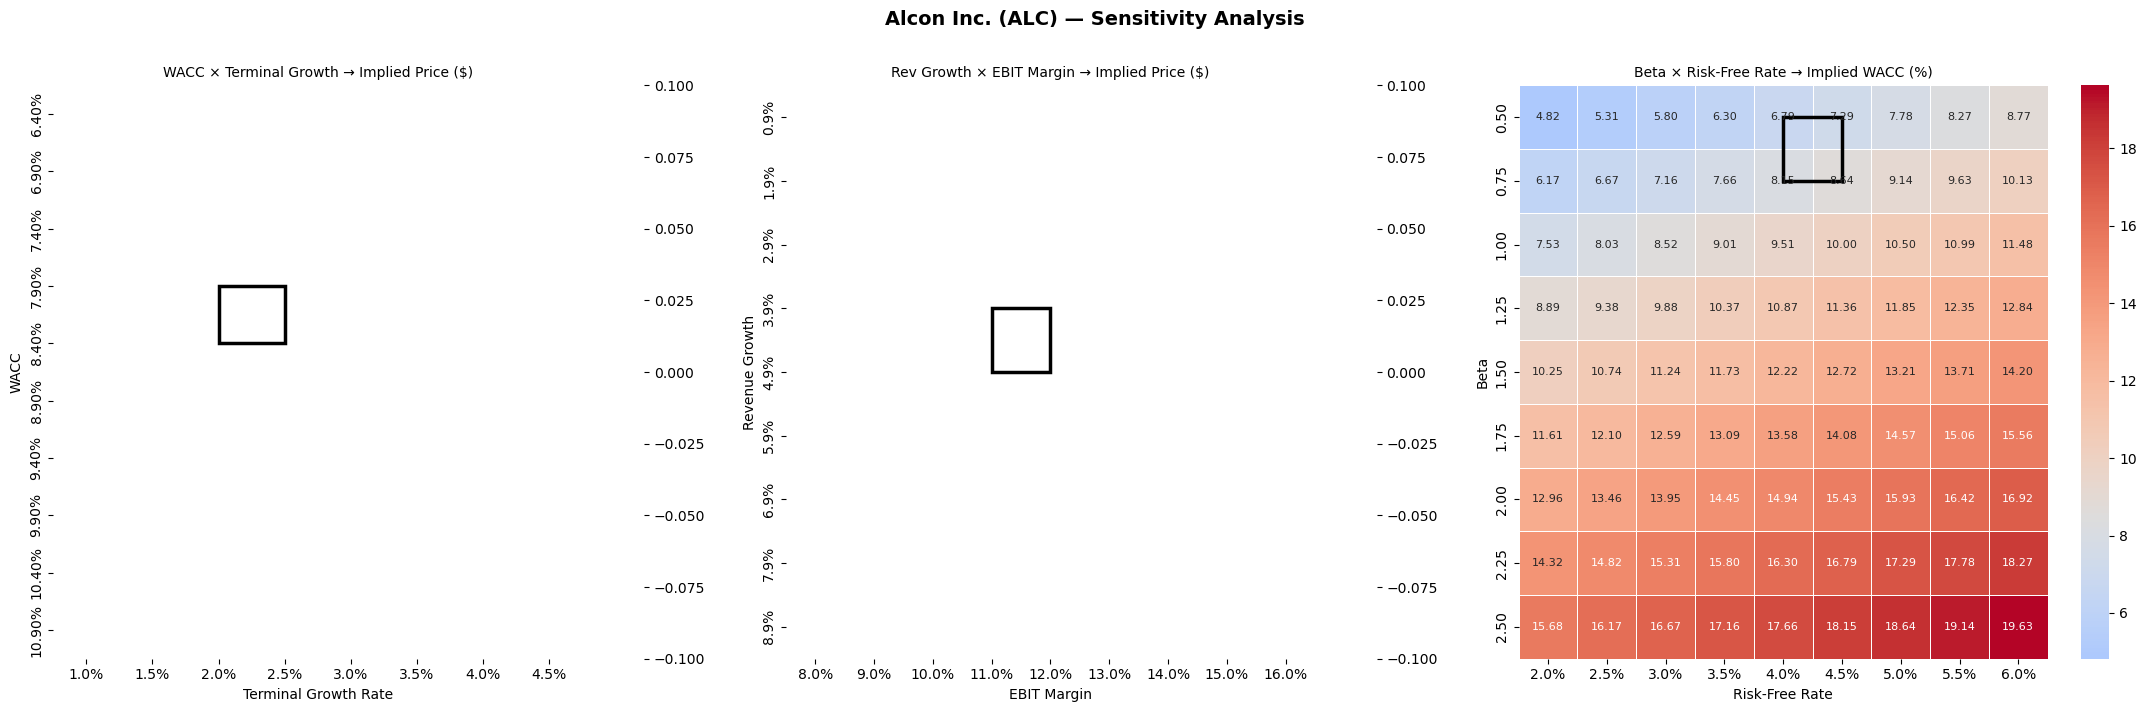

In [36]:
# ============================================================
# CELL 10 — SENSITIVITY ANALYSIS (3 HEATMAPS)
# ============================================================

base_sp    = SCENARIOS["Base"]
base_pr    = projection_results["Base"]
base_wacc  = scenario_waccs["Base"]
base_tg    = base_sp["terminal_g"]
base_rg    = base_sp["rev_growth"]
base_em    = base_sp["ebit_margin"]
base_rev0  = float(revenue[-1])
base_fcf5  = base_pr["fcf"][-1]

def _implied_price_ggm(rg_, em_, w_, tg_):
    """Quick DCF+GGM implied price given scalar scenario params."""
    pr_rev = base_rev0
    s_pv = 0.0
    fcf_last = 0.0
    ebit_last = 0.0
    for t in range(1, PROJECTION_YEARS + 1):
        r  = pr_rev * (1 + rg_)
        eb = r * em_
        d  = r * da_pct_flat
        no = eb * (1 - tax_rate)
        cx = r * capex_pct_flat
        dn = (r - pr_rev) * nwc_pct
        fc = no + d - cx - dn
        s_pv += fc * (1 + w_) ** (-(t - 0.5))
        fcf_last = fc
        pr_rev = r
    if (w_ <= tg_) or (fcf_last <= 0):
        return np.nan
    TV  = fcf_last * (1 + tg_) / (w_ - tg_)
    PTV = TV * (1 + w_) ** (-4.5)
    ev  = s_pv + PTV
    eq  = ev - net_debt
    return eq / shares_outstanding if shares_outstanding > 0 else np.nan

# ── Heatmap 1: WACC × Terminal g ─────────────────────────────
wacc_range = np.arange(base_wacc - 0.02, base_wacc + 0.0251, 0.005)
tg_range   = np.arange(0.01, 0.0451, 0.005)
hm1 = np.zeros((len(wacc_range), len(tg_range)))
for i, w_ in enumerate(wacc_range):
    for j, tg_ in enumerate(tg_range):
        hm1[i, j] = _implied_price_ggm(base_rg, base_em, w_, tg_)

# ── Heatmap 2: Rev Growth × EBIT Margin ──────────────────────
rg_range = np.arange(base_rg - 0.04, base_rg + 0.0401, 0.01)
em_range = np.arange(base_em - 0.04, base_em + 0.0401, 0.01)
hm2 = np.zeros((len(rg_range), len(em_range)))
for i, rg_ in enumerate(rg_range):
    for j, em_ in enumerate(em_range):
        hm2[i, j] = _implied_price_ggm(rg_, em_, base_wacc, base_tg)

# ── Heatmap 3: Beta × Risk-Free Rate → implied WACC ──────────
beta_range = np.arange(0.5, 2.51, 0.25)
rf_range   = np.arange(0.02, 0.0601, 0.005)
hm3 = np.zeros((len(beta_range), len(rf_range)))
for i, b_ in enumerate(beta_range):
    for j, rf_ in enumerate(rf_range):
        ke_  = rf_ + b_ * ERP + SIZE_PREMIUM
        hm3[i, j] = we * ke_ + wd * Kd_at

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(f"{company_name} ({TICKER}) — Sensitivity Analysis",
             fontsize=14, fontweight="bold", y=1.01)

def highlight_cell(ax, row_idx, col_idx):
    ax.add_patch(plt.Rectangle((col_idx - 0.5, row_idx - 0.5), 1, 1,
                                fill=False, edgecolor="black", lw=2.5))

# — HM1 —
df1 = pd.DataFrame(hm1,
                   index=[f"{w*100:.2f}%" for w in wacc_range],
                   columns=[f"{g*100:.1f}%" for g in tg_range])
center1 = current_price
vmin1   = df1.min().min(); vmax1 = df1.max().max()
sns.heatmap(df1, ax=axes[0], annot=True, fmt=".0f",
            cmap="RdYlGn", center=center1, vmin=vmin1, vmax=vmax1,
            linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title("WACC × Terminal Growth → Implied Price ($)", fontsize=10)
axes[0].set_ylabel("WACC"); axes[0].set_xlabel("Terminal Growth Rate")

# highlight base cell
wi = np.argmin(np.abs(wacc_range - base_wacc))
ti = np.argmin(np.abs(tg_range   - base_tg))
highlight_cell(axes[0], wi, ti)

# — HM2 —
df2 = pd.DataFrame(hm2,
                   index=[f"{r*100:.1f}%" for r in rg_range],
                   columns=[f"{m*100:.1f}%" for m in em_range])
sns.heatmap(df2, ax=axes[1], annot=True, fmt=".0f",
            cmap="RdYlGn", center=current_price,
            linewidths=0.5, annot_kws={"size": 8})
axes[1].set_title("Rev Growth × EBIT Margin → Implied Price ($)", fontsize=10)
axes[1].set_ylabel("Revenue Growth"); axes[1].set_xlabel("EBIT Margin")
ri = np.argmin(np.abs(rg_range - base_rg))
ei = np.argmin(np.abs(em_range - base_em))
highlight_cell(axes[1], ri, ei)

# — HM3 —
df3 = pd.DataFrame(hm3 * 100,
                   index=[f"{b:.2f}" for b in beta_range],
                   columns=[f"{r*100:.1f}%" for r in rf_range])
sns.heatmap(df3, ax=axes[2], annot=True, fmt=".2f",
            cmap="coolwarm", center=wacc * 100,
            linewidths=0.5, annot_kws={"size": 8})
axes[2].set_title("Beta × Risk-Free Rate → Implied WACC (%)", fontsize=10)
axes[2].set_ylabel("Beta"); axes[2].set_xlabel("Risk-Free Rate")
bi  = np.argmin(np.abs(beta_range - beta))
rfi = np.argmin(np.abs(rf_range   - rf_rate))
highlight_cell(axes[2], bi, rfi)

plt.tight_layout()
plt.show()
print()

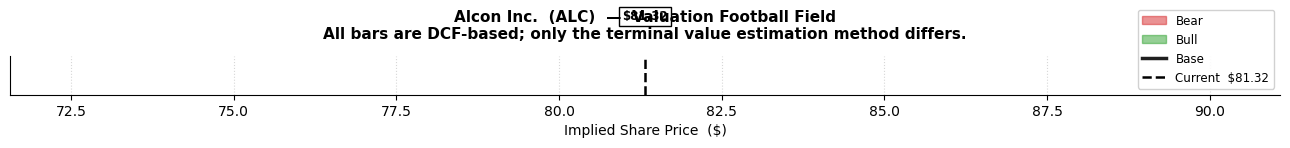

In [37]:
# ============================================================
# CELL 11 — FOOTBALL FIELD CHART (redesigned)
# ============================================================
# Layout: 3 range bars (one per method), Bear→Bull span,
# Base marked as a vertical tick inside the bar.
# Right axis shows % upside/downside from current price.
# ============================================================

method_keys_ff  = ["GGM", "EVEBITDA", "EVEBIT"]
method_names_ff = {
    "GGM":      "DCF (Gordon Growth TV)",
    "EVEBITDA": "DCF (EV/EBITDA Exit TV)",
    "EVEBIT":   "DCF (EV/EBIT Exit TV)",
}

# ── Collect Bear/Base/Bull per method ────────────────────────
ff_ranges = {}
for mkey in method_keys_ff:
    bear = football_data["Bear"][mkey]
    base = football_data["Base"][mkey]
    bull = football_data["Bull"][mkey]
    if any(np.isnan(v) for v in [bear, base, bull]):
        continue
    ff_ranges[mkey] = (bear, base, bull)

n_bars      = len(ff_ranges)
bar_h       = 0.55
gap         = 1.0
y_positions = [i * gap for i in range(n_bars)]

fig, ax = plt.subplots(figsize=(13, 3.5 + n_bars * 0.9))

# ── Determine x-axis bounds (pad 12% each side) ──────────────
all_vals = [v for bear, base, bull in ff_ranges.values() for v in (bear, bull)]
all_vals.append(current_price)
x_lo = min(all_vals) * 0.88
x_hi = max(all_vals) * 1.12

for yi, (mkey, (bear, base, bull)) in zip(y_positions, ff_ranges.items()):
    span = bull - bear

    # Main range bar (Bear → Bull)
    ax.barh(yi, span, left=bear, height=bar_h,
            color="#4C72B0", alpha=0.30, zorder=2)

    # Bear fill (left portion up to base)
    ax.barh(yi, base - bear, left=bear, height=bar_h,
            color="#d62728", alpha=0.25, zorder=3)

    # Bull fill (base to bull)
    ax.barh(yi, bull - base, left=base, height=bar_h,
            color="#2ca02c", alpha=0.25, zorder=3)

    # Outer border
    ax.barh(yi, span, left=bear, height=bar_h,
            color="none", edgecolor="#4C72B0", linewidth=1.5, zorder=4)

    # Base tick (vertical line inside bar)
    ax.plot([base, base],
            [yi - bar_h / 2, yi + bar_h / 2],
            color="#1f1f1f", linewidth=2.5, zorder=5)

    # Price labels with % upside
    def upside_str(p):
        u = (p - current_price) / current_price * 100
        sign = "+" if u >= 0 else ""
        return f"${p:.0f}\n({sign}{u:.1f}%)"

    ax.text(bear - (x_hi - x_lo) * 0.005, yi, upside_str(bear),
            ha="right", va="center", fontsize=7.5,
            color="#d62728", fontweight="bold")
    ax.text(base, yi + bar_h / 2 + 0.06, f"${base:.0f}",
            ha="center", va="bottom", fontsize=7.5,
            color="#1f1f1f", fontweight="bold")
    ax.text(bull + (x_hi - x_lo) * 0.005, yi, upside_str(bull),
            ha="left", va="center", fontsize=7.5,
            color="#2ca02c", fontweight="bold")

# ── Current price line ────────────────────────────────────────
ax.axvline(current_price, color="black", linestyle="--",
           linewidth=1.8, zorder=6)
ax.text(current_price, n_bars * gap - 0.05,
        f"${current_price:.2f}", ha="center", va="bottom",
        fontsize=8.5, fontweight="bold", color="black",
        bbox=dict(fc="white", ec="black", pad=2, lw=1))

# ── Axes formatting ───────────────────────────────────────────
ax.set_yticks(y_positions)
ax.set_yticklabels([method_names_ff[k] for k in ff_ranges],
                   fontsize=10, fontweight="bold")
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(-gap * 0.6, (n_bars - 1) * gap + gap * 0.7)
ax.set_xlabel("Implied Share Price  ($)", fontsize=10)
ax.xaxis.grid(True, linestyle=":", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

# ── Legend ────────────────────────────────────────────────────
legend_els = [
    mpatches.Patch(color="#d62728", alpha=0.5, label="Bear"),
    mpatches.Patch(color="#2ca02c", alpha=0.5, label="Bull"),
    plt.Line2D([0], [0], color="#1f1f1f", lw=2.5, label="Base"),
    plt.Line2D([0], [0], color="black", lw=1.8,
               linestyle="--", label=f"Current  ${current_price:.2f}"),
]
ax.legend(handles=legend_els, fontsize=8.5, loc="lower right",
          framealpha=0.9, edgecolor="#cccccc")

ax.set_title(f"{company_name}  ({TICKER})  —  Valuation Football Field\n"
             f"All bars are DCF-based; only the terminal value estimation method differs.",
             fontsize=11, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()
print()

In [38]:
# ============================================================
# CELL 12 — METHODOLOGY GUIDANCE
# ============================================================

W = 72  # line width

def section(title):
    print(f"\n{'='*W}")
    print(f"  {title}")
    print(f"{'='*W}")

def bullet(label, text, indent=4):
    prefix = " " * indent + f"{label}:  "
    wrap   = W - len(prefix)
    words  = text.split()
    lines, line = [], []
    for w in words:
        if sum(len(x) + 1 for x in line) + len(w) > wrap:
            lines.append(" ".join(line))
            line = [w]
        else:
            line.append(w)
    if line:
        lines.append(" ".join(line))
    print(prefix + lines[0])
    for l in lines[1:]:
        print(" " * len(prefix) + l)

section("WHICH VALUATION METHOD TO TRUST")

print(f"\n  DCF (Gordon Growth Terminal Value)")
print(f"  {'-'*40}")
bullet("Best for",
       "Mature, profitable companies with stable and predictable cash flows "
       "(e.g. consumer staples, industrials, large-cap tech).")
bullet("Use with caution",
       "High-growth companies where terminal value dominates (>70% of EV) — "
       "small assumption changes swing the implied price wildly.")
bullet("Not reliable",
       "Pre-revenue, early-stage, or highly cyclical companies. Also not valid "
       "when projected terminal FCF is negative or when WACC <= g — the perpetuity "
       "formula breaks down and any output is economically meaningless.")

print(f"\n  DCF (EV/EBITDA Exit Terminal Value)")
print(f"  {'-'*40}")
bullet("Best for",
       "Capital-light businesses where EBITDA closely approximates free cash flow "
       "(e.g. software, media, asset-light services).")
bullet("Use with caution",
       "Companies with high CapEx — EBITDA overstates true earnings power by "
       "ignoring capital reinvestment requirements.")
bullet("Not reliable",
       "Financial services, real estate, or heavily capital-intensive industries "
       "(mining, utilities, airlines). Also invalid when projected terminal EBITDA "
       "is negative — applying a positive multiple to a negative base produces a "
       "nonsensical terminal value.")

print(f"\n  DCF (EV/EBIT Exit Terminal Value)  — CapEx-adjusted")
print(f"  {'-'*40}")
bullet("Best for",
       "Capital-intensive industries where CapEx is significant and recurring "
       "(e.g. manufacturing, energy, retail, telecom).")
bullet("Note",
       "More conservative than EV/EBITDA — penalizes companies that require "
       "heavy reinvestment to sustain growth.")
bullet("Not reliable",
       "Financial services, or companies with large non-cash charges that "
       "distort EBIT. Also invalid when projected terminal EBIT is negative.")

# ── Historical P/E check ──────────────────────────────────────
section("HISTORICAL P/E MULTIPLE CHECK")

tpe_str = f"{trailing_pe:.1f}x" if trailing_pe else "N/A"
fpe_str = f"{forward_pe:.1f}x"  if forward_pe  else "N/A"
print(f"\n  Trailing P/E:  {tpe_str}")
print(f"  Forward P/E:   {fpe_str}")

if not np.isnan(current_pe_percentile):
    print(f"  10Y Historical Percentile:  {current_pe_percentile:.0f}th")
    print(f"  Signal:  {pe_status}")
    print()
    if current_pe_percentile >= 75:
        interp = "at a premium relative to its historical norm."
    elif current_pe_percentile <= 25:
        interp = "at a discount relative to its historical norm."
    else:
        interp = "near its historical normal valuation range."
    bullet("Interpretation",
           f"A P/E at the {current_pe_percentile:.0f}th percentile of its own 10-year history "
           f"suggests the market is pricing {company_name} {interp} "
           f"This is a relative-value signal, not a standalone fair-value estimate.")
else:
    print(f"  Historical P/E data:  {pe_status}")
    print(f"  Insufficient history to compute a percentile ranking.")

# ── Company-specific recommendation ──────────────────────────
section(f"SECTOR RECOMMENDATION — {company_name} ({sector})")

_tech_comms   = ["Technology", "Communication Services"]
_industrial   = ["Energy", "Industrials", "Basic Materials"]
_consumer_hc  = ["Consumer Defensive", "Consumer Cyclical", "Healthcare"]
_regulated    = ["Utilities", "Real Estate"]
_financial    = ["Financial Services"]

# Check base-case validity for each method
_ggm_valid      = tv_results["Base"]["GGM"]["valid"]
_evebitda_valid = tv_results["Base"]["EVEBITDA"]["valid"]
_evebit_valid   = tv_results["Base"]["EVEBIT"]["valid"]

if sector in _tech_comms:
    rec = (f"For {company_name}: DCF (EV/EBITDA Exit TV) and DCF (Gordon Growth TV) "
           f"are most relevant. High margins mean EBITDA closely tracks free cash flow. "
           f"Verify that the Gordon Growth terminal value does not exceed 70% of total EV — "
           f"if it does, weight the EV/EBITDA method more heavily.")
elif sector in _industrial:
    rec = (f"For {company_name}: DCF (EV/EBIT Exit TV) is most reliable given significant "
           f"capital expenditure requirements. EBITDA overstates earnings power here. "
           f"Cross-check DCF assumptions against industry reinvestment rates.")
elif sector in _consumer_hc:
    rec = (f"For {company_name}: DCF (Gordon Growth TV) is the anchor method. "
           f"Stable cash flows make long-term projections more reliable. "
           f"Use EV/EBITDA as a sanity check against sector peers.")
elif sector in _regulated:
    rec = (f"For {company_name}: DCF (Gordon Growth TV) is preferred, but consider a "
           f"dividend discount model variant if the company pays consistent dividends. "
           f"EV/EBITDA and EV/EBIT are less meaningful due to regulated capital structures.")
elif sector in _financial:
    rec = (f"For {company_name}: EV-based methods are not meaningful for banks and insurers "
           f"— debt is an input, not capital structure. The Gordon Growth TV is shown but "
           f"treat with caution. Price-to-Book and ROE-based models are more appropriate "
           f"for financial firms.")
else:
    rec = (f"For {company_name}: Review all three methods and weight toward the range "
           f"where two or more methods converge.")

# Append validity caveat if any base-case methods are invalid
if not (_ggm_valid or _evebitda_valid or _evebit_valid):
    rec += (f" NOTE: All three terminal value methods are invalid under base-case "
            f"projections. This typically reflects negative projected operating economics. "
            f"Do not treat any implied prices as reliable fair-value estimates.")
elif not _ggm_valid:
    rec += (f" NOTE: Gordon Growth TV is invalid under base-case projections "
            f"({tv_results['Base']['GGM']['note']}). Weight exit-multiple methods only "
            f"if their terminal metrics are positive.")
elif not _evebitda_valid:
    rec += (f" NOTE: EV/EBITDA TV is invalid under base-case projections "
            f"({tv_results['Base']['EVEBITDA']['note']}). Do not weight this method.")

words  = rec.split()
lines, line = [], []
for w in words:
    if sum(len(x) + 1 for x in line) + len(w) > W - 2:
        lines.append(" ".join(line))
        line = [w]
    else:
        line.append(w)
if line:
    lines.append(" ".join(line))
for l in lines:
    print(f"  {l}")

# ── Convergence check ─────────────────────────────────────────
section("CONVERGENCE CHECK")

base_prices = {k: football_data["Base"][k] for k in ["GGM", "EVEBITDA", "EVEBIT"]}
valid_base  = {k: v for k, v in base_prices.items()
               if not np.isnan(v) and v > 0}

mnames = {
    "GGM":      "Gordon Growth TV",
    "EVEBITDA": "EV/EBITDA Exit TV",
    "EVEBIT":   "EV/EBIT Exit TV",
}

if len(valid_base) == 0:
    print(f"\n  Convergence cannot be assessed — no terminal value method produced a")
    print(f"  positive, economically meaningful implied price under base-case assumptions.")
    print(f"  Review projected operating economics before drawing any valuation conclusions.")
elif len(valid_base) == 1:
    only_k = list(valid_base.keys())[0]
    print(f"\n  Only one valid base-case method: {mnames[only_k]} (${valid_base[only_k]:.2f})")
    print(f"  Convergence cannot be assessed with a single method.")
    print(f"  Cross-check against comparable company multiples or a dividend discount model.")
else:
    vals   = list(valid_base.values())
    spread = (max(vals) - min(vals)) / np.mean(vals) * 100
    print(f"\n  Base-case spread across {len(valid_base)} valid TV methods: {spread:.1f}%")
    if spread <= 20:
        print(f"  ✓ Methods agree within 20% — valuation range is reasonably tight.")
    else:
        print(f"  ⚠ Methods diverge by more than 20%. Re-examine terminal value")
        print(f"    assumptions and exit multiples before drawing conclusions.")
        hi_k = max(valid_base, key=valid_base.get)
        lo_k = min(valid_base, key=valid_base.get)
        print(f"    Highest: {mnames[hi_k]} (${valid_base[hi_k]:.2f})")
        print(f"    Lowest:  {mnames[lo_k]} (${valid_base[lo_k]:.2f})")

print(f"\n  {'='*W}")
print()


  WHICH VALUATION METHOD TO TRUST

  DCF (Gordon Growth Terminal Value)
  ----------------------------------------
    Best for:  Mature, profitable companies with stable and predictable
               cash flows (e.g. consumer staples, industrials, large-cap
               tech).
    Use with caution:  High-growth companies where terminal value
                       dominates (>70% of EV) — small assumption changes
                       swing the implied price wildly.
    Not reliable:  Pre-revenue, early-stage, or highly cyclical
                   companies. Also not valid when projected terminal FCF
                   is negative or when WACC <= g — the perpetuity
                   formula breaks down and any output is economically
                   meaningless.

  DCF (EV/EBITDA Exit Terminal Value)
  ----------------------------------------
    Best for:  Capital-light businesses where EBITDA closely
               approximates free cash flow (e.g. software, media,
         

In [39]:
# ============================================================
# CELL 13 — RECENT NEWS
# ============================================================

from IPython.display import display, HTML
from datetime import datetime, timezone

_news = tkr.news or []
_articles = [a for a in _news if a.get("link") and a.get("title")][:5]

if not _articles:
    print(f"No recent news found for {TICKER}.")
else:
    rows_html = ""
    for i, a in enumerate(_articles, 1):
        title     = a.get("title", "No title")
        link      = a.get("link", "#")
        publisher = a.get("publisher") or a.get("source", {}).get("homepage", "Unknown")
        ts        = a.get("providerPublishTime")
        date_str  = (datetime.fromtimestamp(ts, tz=timezone.utc)
                     .strftime("%b %d, %Y") if ts else "")

        rows_html += f"""
        <tr>
          <td style="padding:6px 10px;color:#888;font-size:12px;vertical-align:top;
                     white-space:nowrap;">{i}</td>
          <td style="padding:6px 10px;vertical-align:top;">
            <a href="{link}" target="_blank"
               style="font-size:13.5px;font-weight:600;color:#1a6fc4;
                      text-decoration:none;line-height:1.4;">
              {title}
            </a><br>
            <span style="font-size:11px;color:#888;">
              {publisher}{('  ·  ' + date_str) if date_str else ''}
            </span>
          </td>
        </tr>"""

    html = f"""
    <div style="font-family:sans-serif;margin-top:8px;">
      <div style="font-size:15px;font-weight:700;margin-bottom:8px;
                  border-bottom:2px solid #e0e0e0;padding-bottom:4px;">
        Recent News — {company_name} ({TICKER})
      </div>
      <table style="border-collapse:collapse;width:100%;">
        {rows_html}
      </table>
    </div>"""

    display(HTML(html))

No recent news found for ALC.
